In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/login_data.csv")

df.head()

,user_id,timestamp,ip_address,country,device_type,browser,login_status,failed_attempts
0,U001,3/20/2026 8:12,192.168.1.1,USA,Mobile,Chrome,Success,0
1,U002,3/20/2026 8:15,192.168.1.2,USA,Laptop,Edge,Failure,3
2,U003,3/21/2026 9:20,10.0.0.1,Nigeria,Mobile,Chrome,Failure,5
3,U001,3/21/2026 9:25,192.168.1.1,USA,Mobile,Chrome,Success,0
4,U004,3/22/2026 10:30,172.16.0.1,UK,Desktop,Firefox,Failure,4


In [3]:
df.shape

(20, 8)

In [4]:
df.columns

Index(['user_id', 'timestamp', 'ip_address', 'country', 'device_type',
       'browser', 'login_status', 'failed_attempts'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_id          20 non-null     str  
 1   timestamp        20 non-null     str  
 2   ip_address       20 non-null     str  
 3   country          20 non-null     str  
 4   device_type      20 non-null     str  
 5   browser          20 non-null     str  
 6   login_status     20 non-null     str  
 7   failed_attempts  20 non-null     int64
dtypes: int64(1), str(7)
memory usage: 1.4 KB


In [6]:
df.isnull().sum()

user_id            0
timestamp          0
ip_address         0
country            0
device_type        0
browser            0
login_status       0
failed_attempts    0
dtype: int64

In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          20 non-null     str           
 1   timestamp        20 non-null     datetime64[us]
 2   ip_address       20 non-null     str           
 3   country          20 non-null     str           
 4   device_type      20 non-null     str           
 5   browser          20 non-null     str           
 6   login_status     20 non-null     str           
 7   failed_attempts  20 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(6)
memory usage: 1.4 KB


In [9]:
df["login_status"].value_counts()

login_status
Failure    14
Success     6
Name: count, dtype: int64

In [10]:
df["user_id"].nunique()

12

In [11]:
df["ip_address"].nunique()

13

In [12]:
df["country"].value_counts()

country
USA        6
Nigeria    5
Unknown    5
UK         2
Canada     2
Name: count, dtype: int64

In [13]:
failed_df = df[df["login_status"] == "Failure"]
failed_df.head()

,user_id,timestamp,ip_address,country,device_type,browser,login_status,failed_attempts
1,U002,2026-03-20 08:15:00,192.168.1.2,USA,Laptop,Edge,Failure,3
2,U003,2026-03-21 09:20:00,10.0.0.1,Nigeria,Mobile,Chrome,Failure,5
4,U004,2026-03-22 10:30:00,172.16.0.1,UK,Desktop,Firefox,Failure,4
6,U002,2026-03-23 12:40:00,192.168.1.2,USA,Laptop,Edge,Failure,6
8,U006,2026-03-24 14:50:00,8.8.8.8,Unknown,Desktop,Chrome,Failure,10


In [14]:
failed_df.shape

(14, 8)

In [15]:
failed_df["ip_address"].value_counts().head(10)

ip_address
8.8.8.8          3
45.33.32.1       3
192.168.1.2      2
10.0.0.1         1
172.16.0.1       1
8.8.4.4          1
203.0.113.5      1
192.0.2.1        1
198.51.100.45    1
Name: count, dtype: int64

In [16]:
failed_df["user_id"].value_counts().head(10)

user_id
U006    3
U001    3
U002    2
U003    1
U004    1
U007    1
U008    1
U010    1
U012    1
Name: count, dtype: int64

In [17]:
ip_failures = failed_df.groupby("ip_address").size().reset_index(name="failed_attempts")
ip_failures = ip_failures.sort_values(by="failed_attempts", ascending=False)
ip_failures.head(10)

,ip_address,failed_attempts
8,8.8.8.8,3
6,45.33.32.1,3
3,192.168.1.2,2
0,10.0.0.1,1
1,172.16.0.1,1
4,198.51.100.45,1
2,192.0.2.1,1
5,203.0.113.5,1
7,8.8.4.4,1


In [18]:
ip_failures["risk_level"] = ip_failures["failed_attempts"].apply(
    lambda x: "High" if x >= 5 else "Medium" if x >= 3 else "Low"
)
ip_failures.head(10)

,ip_address,failed_attempts,risk_level
8,8.8.8.8,3,Medium
6,45.33.32.1,3,Medium
3,192.168.1.2,2,Low
0,10.0.0.1,1,Low
1,172.16.0.1,1,Low
4,198.51.100.45,1,Low
2,192.0.2.1,1,Low
5,203.0.113.5,1,Low
7,8.8.4.4,1,Low


In [19]:
user_failures = failed_df.groupby("user_id").size().reset_index(name="failed_attempts")
user_failures = user_failures.sort_values(by="failed_attempts", ascending=False)
user_failures.head(10)

,user_id,failed_attempts
0,U001,3
4,U006,3
1,U002,2
2,U003,1
3,U004,1
5,U007,1
6,U008,1
7,U010,1
8,U012,1


In [20]:
user_failures["risk_level"] = user_failures["failed_attempts"].apply(
    lambda x: "High" if x >= 5 else "Medium" if x >= 3 else "Low"
)
user_failures.head(10)

,user_id,failed_attempts,risk_level
0,U001,3,Medium
4,U006,3,Medium
1,U002,2,Low
2,U003,1,Low
3,U004,1,Low
5,U007,1,Low
6,U008,1,Low
7,U010,1,Low
8,U012,1,Low


In [21]:
df["hour"] = df["timestamp"].dt.hour
df["hour"].value_counts().sort_index()

hour
2     3
3     1
4     1
8     2
9     2
10    1
11    1
12    1
13    1
14    1
15    1
16    1
18    1
21    3
Name: count, dtype: int64

In [22]:
failed_df = df[df["login_status"] == "Failed"]
failed_df["hour"].value_counts().sort_index()

Series([], Name: count, dtype: int64)

In [23]:
failed_df["country"].value_counts()

Series([], Name: count, dtype: int64)

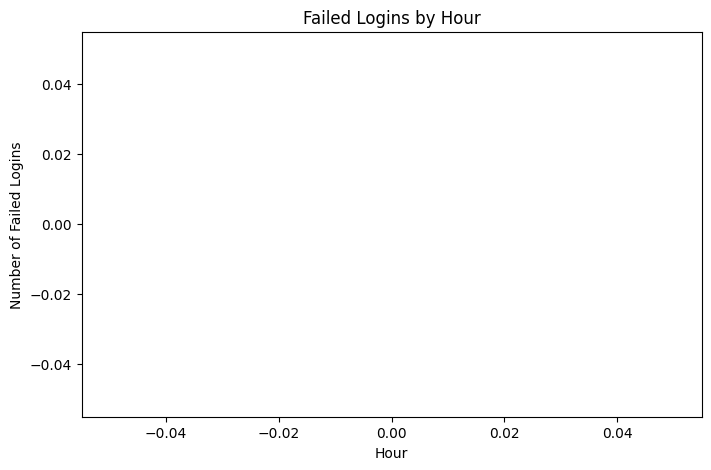

In [24]:
hour_counts = failed_df["hour"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(hour_counts.index.astype(str), hour_counts.values)
plt.title("Failed Logins by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Failed Logins")
plt.show()

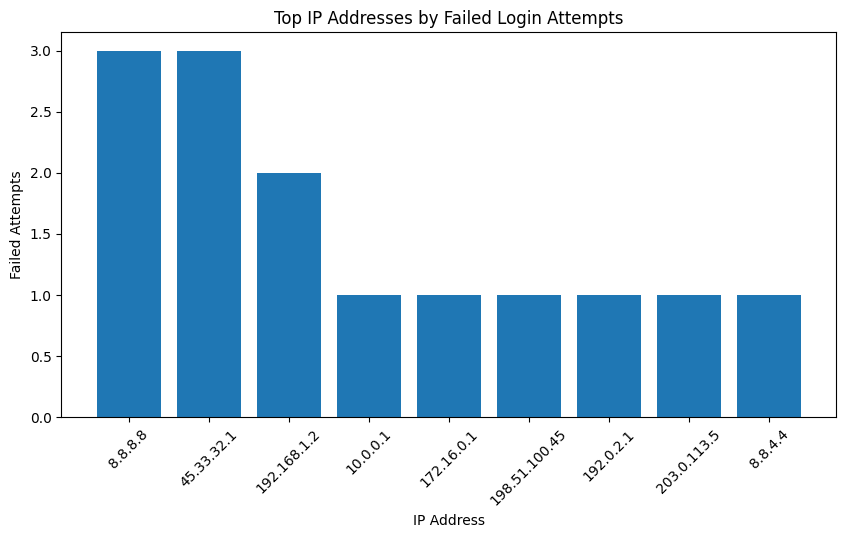

In [25]:
top_ips = ip_failures.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_ips["ip_address"], top_ips["failed_attempts"])

plt.title("Top IP Addresses by Failed Login Attempts")
plt.xlabel("IP Address")
plt.ylabel("Failed Attempts")
plt.xticks(rotation=45)

plt.show()

In [26]:
df["suspicious"] = df["failed_attempts"] >= 5
df.head()

,user_id,timestamp,ip_address,country,device_type,browser,login_status,failed_attempts,hour,suspicious
0,U001,2026-03-20 08:12:00,192.168.1.1,USA,Mobile,Chrome,Success,0,8,False
1,U002,2026-03-20 08:15:00,192.168.1.2,USA,Laptop,Edge,Failure,3,8,False
2,U003,2026-03-21 09:20:00,10.0.0.1,Nigeria,Mobile,Chrome,Failure,5,9,True
3,U001,2026-03-21 09:25:00,192.168.1.1,USA,Mobile,Chrome,Success,0,9,False
4,U004,2026-03-22 10:30:00,172.16.0.1,UK,Desktop,Firefox,Failure,4,10,False


In [27]:
df["suspicious"].value_counts()

suspicious
False    10
True     10
Name: count, dtype: int64

In [28]:
suspicious_df = df[df["suspicious"] == True]

top_suspicious_ips = suspicious_df["ip_address"].value_counts().head(10)
top_suspicious_ips

ip_address
8.8.8.8        3
45.33.32.1     3
10.0.0.1       1
192.168.1.2    1
8.8.4.4        1
203.0.113.5    1
Name: count, dtype: int64

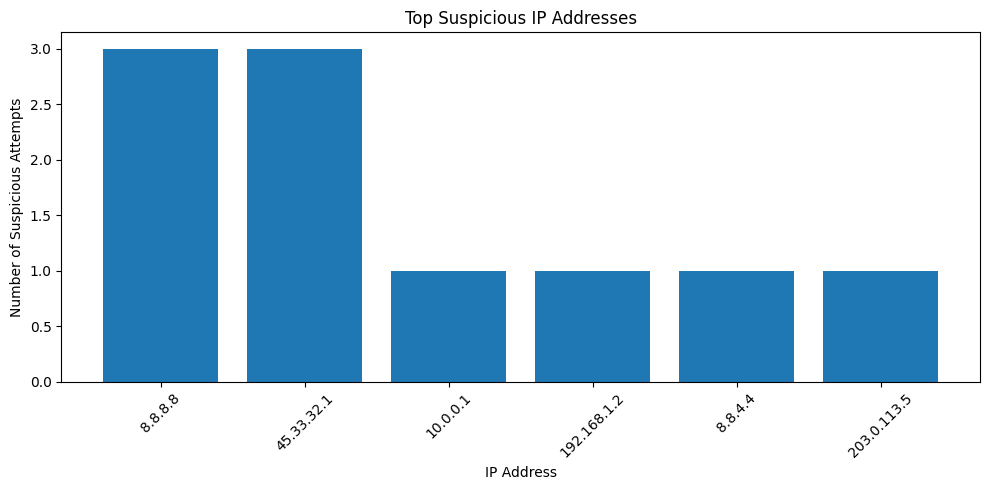

In [29]:
plt.figure(figsize=(10,5))
plt.bar(top_suspicious_ips.index, top_suspicious_ips.values)

plt.title("Top Suspicious IP Addresses")
plt.xlabel("IP Address")
plt.ylabel("Number of Suspicious Attempts")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [30]:
df["login_status"] = df["login_status"].str.strip().str.lower()
failed_df = df[df["login_status"] == "failure"]
ip_failures = failed_df.groupby("ip_address").size().reset_index(name="failed_attempts")
ip_failures = ip_failures.sort_values(by="failed_attempts", ascending=False)
ip_failures.head(10)

,ip_address,failed_attempts
8,8.8.8.8,3
6,45.33.32.1,3
3,192.168.1.2,2
0,10.0.0.1,1
1,172.16.0.1,1
4,198.51.100.45,1
2,192.0.2.1,1
5,203.0.113.5,1
7,8.8.4.4,1


In [31]:
def calculate_risk(row):
    score = 0

    if row["failed_attempts"] >= 3:
        score += 2
    elif row["failed_attempts"] == 2:
        score += 1

    if row["country"].lower() == "unknown":
        score += 1

    if row["device_type"].lower() == "desktop":
        score += 1

    return score


def classify_risk(score):
    if score >= 3:
        return "High Risk"
    elif score == 2:
        return "Medium Risk"
    else:
        return "Low Risk"


df["risk_score"] = df.apply(calculate_risk, axis=1)
df["risk_level"] = df["risk_score"].apply(classify_risk)

df[["ip_address", "failed_attempts", "risk_score", "risk_level"]].head(10)

,ip_address,failed_attempts,risk_score,risk_level
0,192.168.1.1,0,0,Low Risk
1,192.168.1.2,3,2,Medium Risk
2,10.0.0.1,5,2,Medium Risk
3,192.168.1.1,0,0,Low Risk
4,172.16.0.1,4,3,High Risk
5,10.0.0.2,0,0,Low Risk
6,192.168.1.2,6,2,Medium Risk
7,10.0.0.1,0,0,Low Risk
8,8.8.8.8,10,4,High Risk
9,8.8.4.4,8,3,High Risk


In [32]:
user_failures = df[df["login_status"] == "failure"].groupby("user_id").size().reset_index(name="failed_attempts")

user_failures = user_failures.sort_values(by="failed_attempts", ascending=False)

user_failures.head(10)

,user_id,failed_attempts
0,U001,3
4,U006,3
1,U002,2
2,U003,1
3,U004,1
5,U007,1
6,U008,1
7,U010,1
8,U012,1


In [33]:
user_failures["risk_level"] = user_failures["failed_attempts"].apply(
    lambda x: "High Risk" if x >= 5 else "Medium Risk" if x >= 3 else "Low Risk"
)

user_failures.head(10)

,user_id,failed_attempts,risk_level
0,U001,3,Medium Risk
4,U006,3,Medium Risk
1,U002,2,Low Risk
2,U003,1,Low Risk
3,U004,1,Low Risk
5,U007,1,Low Risk
6,U008,1,Low Risk
7,U010,1,Low Risk
8,U012,1,Low Risk


In [34]:
df["hour"] = pd.to_datetime(df["timestamp"]).dt.hour

hourly_failures = df[df["login_status"] == "failure"].groupby("hour").size().reset_index(name="failed_attempts")

hourly_failures = hourly_failures.sort_values(by="failed_attempts", ascending=False)

hourly_failures

,hour,failed_attempts
0,2,3
9,21,3
1,3,1
2,8,1
4,10,1
3,9,1
5,12,1
6,14,1
7,15,1
8,16,1


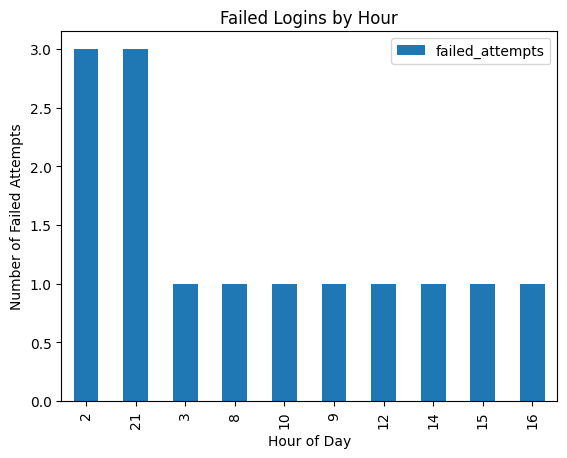

In [35]:
hourly_failures.plot(x="hour", y="failed_attempts", kind="bar")
plt.title("Failed Logins by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Failed Attempts")
plt.show()